# Mask Ablation Experiment — LCLD

Runs all eight mask variants (M0, M1, M2, M3, M4, M5, M6-strict, M6-relaxed) on LCLD with the neural model and CAPGD attack. All variants are produced inside one seed loop against the same trained model per seed — no cross-run mixing. Historical `comparison_*.csv` baselines are copied from Drive as optional cross-reference only.

Produces: per-seed results CSV, seed-42 feasibility audit, seed-42 perturbation statistics, and an E1 cost-weighted evaluation for M0 vs M1.

Reference: `notebooks/tabularbench_comparison.ipynb` (reused setup + utility functions).
Spec: `docs/plans/mask_ablation_experiment_plan.md`.

In [1]:
# Cell 1: Verify GPU
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    gpu_mem = getattr(props, "total_memory", getattr(props, "total_mem", 0)) / 1e9
    print(f"GPU: {gpu_name} ({gpu_mem:.1f} GB)")
else:
    print("WARNING: No GPU detected. Go to Runtime > Change runtime type > GPU")

GPU: NVIDIA A100-SXM4-40GB (42.4 GB)


In [2]:
# Cell 2: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
DRIVE_ROOT = "/content/drive/MyDrive/FraudBench"
for subdir in ["data", "results", "results/adv_examples"]:
    os.makedirs(os.path.join(DRIVE_ROOT, subdir), exist_ok=True)
print("Google Drive mounted.")

Mounted at /content/drive
Google Drive mounted.


In [3]:
# Cell 3: Clone or update repo
import os, shutil

REPO_URL = "https://github.com/iHaydenzZ/Capstone_FraudBench.git"
REPO_DIR = "/content/Capstone_FraudBench"

if os.path.exists(os.path.join(REPO_DIR, ".git")):
    os.chdir(REPO_DIR)
    !git pull
else:
    os.chdir("/content")
    if os.path.exists(REPO_DIR):
        shutil.rmtree(REPO_DIR)
    !git clone {REPO_URL} {REPO_DIR}
    os.chdir(REPO_DIR)

print(f"Working directory: {os.getcwd()}")
!git log --oneline -3

Cloning into '/content/Capstone_FraudBench'...
remote: Enumerating objects: 849, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 849 (delta 2), reused 2 (delta 1), pack-reused 839 (from 1)
Receiving objects: 100% (849/849), 2.30 MiB | 10.50 MiB/s, done.
Resolving deltas: 100% (540/540), done.
Working directory: /content/Capstone_FraudBench
9a7a634 (HEAD -> master, origin/master, origin/HEAD) fix(mask-ablation): run M0/M1 inside variant loop for apples-to-apples comparison
fe45ca6 Merge branch 'feat/mask-ablation'
99c224c fix(mask-ablation): exact-match direction resolver; recover emp_length in E1


In [4]:
# Cell 4: Install dependencies
# Colab's pre-installed numpy/scipy can conflict with project deps.
# Force a compatible set, then restart the runtime so the C extensions reload.
!pip install "numpy<2.1" "scipy>=1.14,<1.15" "scikit-learn>=1.5" -q 2>&1 | tail -5
!pip install -e . --no-deps -q 2>&1 | tail -5
!pip install "numba>=0.61" -q 2>&1 | tail -3
!pip install xgboost torch art pyyaml joblib pandas -q 2>&1 | tail -3

# --- IMPORTANT ---
# After this cell finishes, restart the runtime:
#   Runtime > Restart session  (or Ctrl+M then .)
# Then skip this cell and continue from Cell 5.
# The restart is needed because Colab caches numpy's C extensions in memory.
print("\n>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 70.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.0 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.3/72.3 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.4/610.4 kB 47.2 MB/s eta 0:00:00

>>> RESTART THE RUNTIME NOW, then skip this cell and run from Cell 5. <<<


In [1]:
# Cell 5: Symlink datasets from Google Drive
import os

DRIVE_DATA = "/content/drive/MyDrive/FraudBench/data"
DATASETS_DIR = "/content/Capstone_FraudBench/datasets"

for dataset_dir in ["CCFD", "ieee-fraud-detection", "LCLD", "Sparkov"]:
    src = os.path.join(DRIVE_DATA, dataset_dir)
    dst = os.path.join(DATASETS_DIR, dataset_dir)
    if os.path.islink(dst):
        os.unlink(dst)
    if os.path.exists(src):
        os.symlink(src, dst)
        print(f"  Linked: {dataset_dir}/")
    else:
        print(f"  NOT FOUND: {dataset_dir}/ -- upload to {src}")

print("Dataset symlinks ready.")

  Linked: CCFD/
  Linked: ieee-fraud-detection/
  Linked: LCLD/
  Linked: Sparkov/
Dataset symlinks ready.


In [2]:
# Cell 6: Mask variant configuration
#
# M3/M4/M5 are defined by their IMMUTABLE raw-feature sets (extends LCLD_IMMUTABLE_RAW).
# M6-strict and M6-relaxed are defined by their MUTABLE raw-feature sets; the experiment
# loop (Cell 8) inverts them against dataset.X.columns to get the immutable set to
# pass into build_processed_mutable_mask().

from typing import Set

# --- Baseline immutable set (copied verbatim from tabularbench_comparison.ipynb Cell 6) ---
LCLD_IMMUTABLE_RAW: Set[str] = {
    # LC internal pricing/grading
    "grade", "sub_grade", "int_rate", "installment",
    "funded_amnt", "funded_amnt_inv", "initial_list_status",
    # LC verification outcomes
    "verification_status", "verification_status_joint",
    # Credit bureau data
    "delinq_2yrs", "inq_last_6mths", "inq_last_12m", "inq_fi",
    "open_acc", "open_acc_6m", "open_act_il",
    "open_il_12m", "open_il_24m", "open_rv_12m", "open_rv_24m",
    "pub_rec", "pub_rec_bankruptcies", "total_acc",
    "revol_bal", "revol_util", "il_util", "all_util",
    "tot_cur_bal", "tot_hi_cred_lim", "total_bal_il",
    "total_rev_hi_lim", "max_bal_bc",
    "pct_tl_nvr_dlq", "percent_bc_gt_75",
    "collections_12_mths_ex_med",
    "mths_since_last_delinq", "mths_since_last_il_delinq",
    "mths_since_last_major_delinq", "mths_since_last_record",
    "mths_since_rcnt_il",
    "payment_inc_ratio",
}

LCLD_MUTABLE_RAW: Set[str] = {
    "loan_amnt", "term", "purpose", "emp_length",
    "annual_inc", "annual_inc_joint", "home_ownership",
    "dti", "dti_joint", "application_type", "addr_state",
}

# --- Variant immutable sets ---
LCLD_IMMUTABLE_M3 = LCLD_IMMUTABLE_RAW | {"dti", "dti_joint"}
LCLD_IMMUTABLE_M4 = LCLD_IMMUTABLE_RAW | {"term"}
LCLD_IMMUTABLE_M5 = LCLD_IMMUTABLE_RAW | {"dti", "dti_joint", "term"}

# --- M6 attacker-capability profiles ---
MUTABLE_STRICT: Set[str] = {
    "loan_amnt", "purpose", "home_ownership", "application_type", "addr_state",
}
MUTABLE_RELAXED: Set[str] = {
    "loan_amnt", "purpose", "home_ownership", "application_type", "addr_state",
    "annual_inc", "annual_inc_joint", "emp_length",
}

# --- M2 directionality ---
# Only emp_length is increase-only among LCLD mutable features.
DIRECTION_CONSTRAINTS = {"emp_length": "increase"}

# --- E1 cost weights (raw-space, normalized units) ---
FEATURE_COSTS = {
    "loan_amnt":        1.0,
    "purpose":          0.5,
    "home_ownership":   3.0,
    "addr_state":       2.0,
    "application_type": 1.0,
    "annual_inc":       8.0,
    "annual_inc_joint": 8.0,
    "emp_length":       5.0,
    "dti":              7.0,
    "dti_joint":        7.0,
    "term":             1.0,
}

# --- Sanity checks ---
assert LCLD_IMMUTABLE_RAW.isdisjoint(LCLD_MUTABLE_RAW), "raw sets overlap"
assert set(FEATURE_COSTS.keys()) == LCLD_MUTABLE_RAW, "cost dict must cover all mutable features"
assert MUTABLE_STRICT <= LCLD_MUTABLE_RAW, "strict profile contains non-mutable feature"
assert MUTABLE_RELAXED <= LCLD_MUTABLE_RAW, "relaxed profile contains non-mutable feature"
assert LCLD_IMMUTABLE_M5 == LCLD_IMMUTABLE_M3 | LCLD_IMMUTABLE_M4, "M5 must equal M3 ∪ M4"
assert all(v in {"increase", "decrease"} for v in DIRECTION_CONSTRAINTS.values()), "unknown direction constraint"

print(f"Baseline mutable:   {len(LCLD_MUTABLE_RAW)} raw features")
print(f"M3 locks adds:      {sorted(LCLD_IMMUTABLE_M3 - LCLD_IMMUTABLE_RAW)}")
print(f"M4 locks adds:      {sorted(LCLD_IMMUTABLE_M4 - LCLD_IMMUTABLE_RAW)}")
print(f"M5 locks adds:      {sorted(LCLD_IMMUTABLE_M5 - LCLD_IMMUTABLE_RAW)}")
print(f"M6-strict mutable:  {sorted(MUTABLE_STRICT)} ({len(MUTABLE_STRICT)} features)")
print(f"M6-relaxed mutable: {sorted(MUTABLE_RELAXED)} ({len(MUTABLE_RELAXED)} features)")

Baseline mutable:   11 raw features
M3 locks adds:      ['dti', 'dti_joint']
M4 locks adds:      ['term']
M5 locks adds:      ['dti', 'dti_joint', 'term']
M6-strict mutable:  ['addr_state', 'application_type', 'home_ownership', 'loan_amnt', 'purpose'] (5 features)
M6-relaxed mutable: ['addr_state', 'annual_inc', 'annual_inc_joint', 'application_type', 'emp_length', 'home_ownership', 'loan_amnt', 'purpose'] (8 features)


In [3]:
# Cell 7: Build processed-space mutability mask & define masked CAPGD
#
# After OneHotEncoding, categorical features expand:
#   "grade" -> "grade_A", "grade_B", ...
# All expanded columns from an immutable raw feature are also immutable.
#
# The existing project_constraints() already reverts non-numeric (OHE)
# features to original values, so those are effectively immutable.
# This mask additionally locks NUMERIC immutable features.

import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from typing import Dict, Any, Optional, Set


def build_processed_mutable_mask(
    processed_feature_names: list,
    immutable_raw: Set[str],
) -> np.ndarray:
    """
    Build a boolean mask over processed (post-OHE) features.
    True = mutable (can be perturbed), False = immutable.

    OHE columns are named like "purpose_debt_consolidation" -- the prefix
    before the first underscore that matches a raw feature name determines
    mutability. For ambiguous cases (multiple underscores), we try
    progressively longer prefixes.
    """
    mask = np.ones(len(processed_feature_names), dtype=bool)  # default: mutable

    for i, col in enumerate(processed_feature_names):
        # Direct match (numeric features keep their name)
        if col in immutable_raw:
            mask[i] = False
            continue

        # OHE match: try prefixes "X" from "X_value"
        # e.g. "verification_status_Verified" -> try "verification_status"
        parts = col.split("_")
        for k in range(1, len(parts)):
            prefix = "_".join(parts[:k])
            if prefix in immutable_raw:
                mask[i] = False
                break

    return mask


def capgd_attack_masked(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    schema,  # ConstraintSchema
    feature_types: Dict[str, str],
    mutable_mask: np.ndarray,
    params: Dict[str, Any] = None,
) -> pd.DataFrame:
    """
    CAPGD attack with mutability mask.
    Identical to attacks/capgd.py but zeroes gradients on immutable features.
    """
    from attacks.capgd import project_constraints

    if params is None:
        params = {}

    epsilon = params.get("epsilon", 0.1)
    steps = params.get("steps", 10)
    step_size = params.get("step_size", epsilon / 4)

    if not hasattr(model, "model") or not isinstance(model.model, nn.Module):
        print("Warning: Model is not PyTorch. Returning clean data.")
        return X

    torch_model = model.model
    device = model.device
    torch_model.eval()

    X_tensor = torch.tensor(X.values, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1).to(device)
    feature_names = X.columns.tolist()

    # Convert mask to torch tensor on device
    mutable_t = torch.tensor(mutable_mask, dtype=torch.bool).to(device)

    # Random init within epsilon ball
    noise = torch.zeros_like(X_tensor).uniform_(-epsilon, epsilon)
    noise[:, ~mutable_t] = 0  # no perturbation on immutable features
    x_adv = X_tensor + noise
    x_adv = project_constraints(x_adv, X_tensor, schema, feature_names, feature_types)
    x_adv = x_adv.detach()
    x_adv.requires_grad = True

    use_logits = hasattr(model, "_use_logits") and model._use_logits
    criterion = nn.BCEWithLogitsLoss() if use_logits else nn.BCELoss()

    for step in range(steps):
        outputs = torch_model(x_adv)
        loss = criterion(outputs, y_tensor)

        torch_model.zero_grad()
        loss.backward()

        with torch.no_grad():
            grad = x_adv.grad
            grad[:, ~mutable_t] = 0  # KEY: zero gradients on immutable features

            x_adv = x_adv + step_size * grad.sign()

            # Project onto epsilon ball
            if epsilon > 0:
                delta = x_adv - X_tensor
                delta = torch.clamp(delta, -epsilon, epsilon)
                delta[:, ~mutable_t] = 0  # enforce zero delta on immutable
                x_adv = X_tensor + delta

            # Project onto feasibility constraints
            x_adv = project_constraints(
                x_adv, X_tensor, schema, feature_names, feature_types
            )
            x_adv.requires_grad = True

    return pd.DataFrame(
        x_adv.detach().cpu().numpy(), columns=feature_names, index=X.index
    )


print("Masked CAPGD function defined.")

def capgd_attack_masked_directional(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    schema,
    feature_types: Dict[str, str],
    mutable_mask: np.ndarray,
    direction_cols: Dict[int, str],  # {processed_col_idx: "increase"|"decrease"}
    params: Dict[str, Any] = None,
) -> pd.DataFrame:
    """
    CAPGD with mask + per-column directional constraints.
    direction_cols maps processed column index to 'increase' (delta >= 0)
    or 'decrease' (delta <= 0). Applied after the epsilon-ball projection
    at every step.
    """
    from attacks.capgd import project_constraints

    if params is None:
        params = {}

    epsilon = params.get("epsilon", 0.1)
    steps = params.get("steps", 10)
    step_size = params.get("step_size", epsilon / 4)

    if not hasattr(model, "model") or not isinstance(model.model, nn.Module):
        print("Warning: Model is not PyTorch. Returning clean data.")
        return X

    torch_model = model.model
    device = model.device
    torch_model.eval()

    X_tensor = torch.tensor(X.values, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y.values, dtype=torch.float32).unsqueeze(1).to(device)
    feature_names = X.columns.tolist()

    mutable_t = torch.tensor(mutable_mask, dtype=torch.bool).to(device)

    # Build directional clip tensors once
    inc_idx = torch.tensor(
        [i for i, d in direction_cols.items() if d == "increase"],
        dtype=torch.long, device=device,
    )
    dec_idx = torch.tensor(
        [i for i, d in direction_cols.items() if d == "decrease"],
        dtype=torch.long, device=device,
    )

    noise = torch.zeros_like(X_tensor).uniform_(-epsilon, epsilon)
    noise[:, ~mutable_t] = 0
    x_adv = X_tensor + noise
    # Apply directional clip to initial noise
    if len(inc_idx) > 0:
        x_adv[:, inc_idx] = torch.maximum(x_adv[:, inc_idx], X_tensor[:, inc_idx])
    if len(dec_idx) > 0:
        x_adv[:, dec_idx] = torch.minimum(x_adv[:, dec_idx], X_tensor[:, dec_idx])
    x_adv = project_constraints(x_adv, X_tensor, schema, feature_names, feature_types)
    x_adv = x_adv.detach()
    x_adv.requires_grad = True

    use_logits = hasattr(model, "_use_logits") and model._use_logits
    criterion = nn.BCEWithLogitsLoss() if use_logits else nn.BCELoss()

    for step in range(steps):
        outputs = torch_model(x_adv)
        loss = criterion(outputs, y_tensor)

        torch_model.zero_grad()
        loss.backward()

        with torch.no_grad():
            grad = x_adv.grad
            grad[:, ~mutable_t] = 0

            x_adv = x_adv + step_size * grad.sign()

            if epsilon > 0:
                delta = x_adv - X_tensor
                delta = torch.clamp(delta, -epsilon, epsilon)
                delta[:, ~mutable_t] = 0
                x_adv = X_tensor + delta

            # Directional clip (processed space; StandardScaler preserves direction)
            if len(inc_idx) > 0:
                x_adv[:, inc_idx] = torch.maximum(x_adv[:, inc_idx], X_tensor[:, inc_idx])
            if len(dec_idx) > 0:
                x_adv[:, dec_idx] = torch.minimum(x_adv[:, dec_idx], X_tensor[:, dec_idx])

            x_adv = project_constraints(
                x_adv, X_tensor, schema, feature_names, feature_types
            )
            x_adv.requires_grad = True

    return pd.DataFrame(
        x_adv.detach().cpu().numpy(), columns=feature_names, index=X.index
    )


print("Directional CAPGD function defined.")

def resolve_direction_indices(
    processed_feature_names: list,
    direction_raw: Dict[str, str],
) -> Dict[int, str]:
    """Map raw feature directional config to processed column indices.

    Exact-match only: OHE-expanded categoricals have no meaningful
    per-column direction, so prefix matching would silently apply a bogus
    constraint to every OHE column. Features whose raw name does not exist
    as a processed column (e.g. a categorical like LCLD's emp_length) are
    skipped with a warning — M2 becomes a no-op for such features.
    """
    out: Dict[int, str] = {}
    matched_raw: Set[str] = set()
    for i, col in enumerate(processed_feature_names):
        if col in direction_raw:
            out[i] = direction_raw[col]
            matched_raw.add(col)
    missing = set(direction_raw.keys()) - matched_raw
    if missing:
        print(
            f"[M2 warning] direction constraints on {sorted(missing)} had no "
            "effect: those features are not numeric columns in processed space "
            "(likely OHE-encoded categorical). M2 will be equivalent to M1 "
            "for these features."
        )
    return out


print("Direction index resolver defined.")

Masked CAPGD function defined.
Directional CAPGD function defined.
Direction index resolver defined.


In [4]:
# Cell 8: Main experiment loop — train once per seed, run all 6 new variants
import time
import os
import numpy as np
import pandas as pd

from datasets.loader import load_dataset
from datasets.splitter import split_dataset
from preprocessing.processor import DataPreprocessor, get_preprocessor_path
from constraints.schema import ConstraintSchema
from models.neural import NeuralModel
from evaluation.metrics import compute_metrics

SEEDS = [42, 123, 456]
EPSILON = 0.1
SAMPLE_FRAC = 0.1
ATTACK_PARAMS = {"epsilon": EPSILON, "steps": 10, "step_size": EPSILON / 4}
MODEL_PARAMS = {"epochs": 20, "hidden_dim": 128, "batch_size": 256, "lr": 0.001}

ADV_SAVE_DIR = "results/adv_examples/mask_ablation"
os.makedirs(ADV_SAVE_DIR, exist_ok=True)

# {variant_name: (attack_fn_kind, immutable_set_or_None, extra)}
# attack_fn_kind in {"masked", "directional"}.
# For M6 the immutable set is computed per-seed from dataset.X.columns.
VARIANTS = {
    "M0":         ("masked",      set(),              {}),
    "M1":         ("masked",      LCLD_IMMUTABLE_RAW, {}),
    "M2":         ("directional", LCLD_IMMUTABLE_RAW, {"direction": DIRECTION_CONSTRAINTS}),
    "M3":         ("masked",      LCLD_IMMUTABLE_M3,  {}),
    "M4":         ("masked",      LCLD_IMMUTABLE_M4,  {}),
    "M5":         ("masked",      LCLD_IMMUTABLE_M5,  {}),
    "M6strict":   ("masked",      "from_profile",     {"profile": MUTABLE_STRICT}),
    "M6relaxed":  ("masked",      "from_profile",     {"profile": MUTABLE_RELAXED}),
}

rows = []  # per-(variant, seed) row for mask_ablation_results.csv

for seed in SEEDS:
    print(f"\n{'='*60}\n  SEED = {seed}\n{'='*60}")

    # --- Load, split, preprocess (reuse saved preprocessor) ---
    dataset = load_dataset("lcld", config={"sample_frac": SAMPLE_FRAC})
    X_train, X_val, X_test, y_train, y_val, y_test = split_dataset(
        dataset, test_size=0.2, val_size=0.2, random_state=seed,
    )
    # Always refit so the preprocessor is built with the Colab runtime's sklearn
    # version (avoids InconsistentVersionWarning from stale joblibs) and so the
    # full pipeline — train, preprocess, attack — is internally consistent.
    preprocessor = DataPreprocessor(dataset.feature_types)
    X_train_p = preprocessor.fit_transform(X_train)
    X_test_p = preprocessor.transform(X_test)
    preprocessor_path = get_preprocessor_path("lcld", seed, len(dataset.X))
    preprocessor.save(preprocessor_path)
    processed_feature_types = {c: "numeric" for c in X_train_p.columns}
    processed_schema = ConstraintSchema.from_data(X_train_p, processed_feature_types)
    print(f"  Data: train={len(X_train)}, test={len(X_test)}, processed={X_test_p.shape[1]}")

    # --- Train once ---
    model = NeuralModel(MODEL_PARAMS)
    t0 = time.time()
    model.fit(X_train_p, y_train)
    print(f"  Trained in {time.time()-t0:.1f}s")

    clean_probs = model.predict_proba(X_test_p)
    clean_metrics = compute_metrics(y_test, clean_probs)
    print(f"  Clean  -- PR-AUC: {clean_metrics['pr_auc']:.4f}, Acc: {clean_metrics['accuracy']:.4f}")

    # Raw feature universe for M6 immutable-set construction
    raw_all = set(dataset.X.columns)

    # --- Loop over variants ---
    for vname, (kind, imm, extra) in VARIANTS.items():
        if imm == "from_profile":
            immutable_raw = raw_all - extra["profile"]
        else:
            immutable_raw = imm

        mutable_mask = build_processed_mutable_mask(
            X_test_p.columns.tolist(), immutable_raw
        )
        n_mut = int(mutable_mask.sum())
        n_imm = int((~mutable_mask).sum())

        t0 = time.time()
        if kind == "directional":
            dir_idx = resolve_direction_indices(
                X_test_p.columns.tolist(), extra["direction"]
            )
            X_adv = capgd_attack_masked_directional(
                model, X_test_p, y_test, processed_schema, processed_feature_types,
                mutable_mask, dir_idx, params=ATTACK_PARAMS,
            )
        else:
            X_adv = capgd_attack_masked(
                model, X_test_p, y_test, processed_schema, processed_feature_types,
                mutable_mask, params=ATTACK_PARAMS,
            )
        dt = time.time() - t0

        robust_probs = model.predict_proba(X_adv)
        robust = compute_metrics(y_test, robust_probs)
        print(
            f"  {vname:10s} mut={n_mut:3d} imm={n_imm:3d} "
            f"-- Robust PR-AUC: {robust['pr_auc']:.4f}, Acc: {robust['accuracy']:.4f} ({dt:.1f}s)"
        )

        parquet_path = os.path.join(ADV_SAVE_DIR, f"lcld_neural_{vname}_seed{seed}.parquet")
        X_adv.to_parquet(parquet_path)

        rows.append({
            "variant": vname, "seed": seed,
            "n_mutable": n_mut, "n_immutable": n_imm,
            "clean_pr_auc":  clean_metrics["pr_auc"],
            "clean_accuracy": clean_metrics["accuracy"],
            "clean_recall":   clean_metrics.get("recall", np.nan),
            "clean_f1":       clean_metrics.get("f1", np.nan),
            "robust_pr_auc":  robust["pr_auc"],
            "robust_accuracy": robust["accuracy"],
            "robust_recall":   robust.get("recall", np.nan),
            "robust_f1":       robust.get("f1", np.nan),
            "attack_time_s": dt,
        })

results_df = pd.DataFrame(rows)
results_df.to_csv(os.path.join(ADV_SAVE_DIR, "mask_ablation_results.csv"), index=False)
print(f"\nSaved per-seed results to {ADV_SAVE_DIR}/mask_ablation_results.csv")
print(results_df)


  SEED = 42
    Split indices saved to results/split_indices_lcld_n134097_seed42.json
    Preprocessor saved to results/preprocessor_lcld_n134097_seed42.joblib
  Data: train=80457, test=26820, processed=188
  Using class weights (pos_weight=4.11)
Training Neural Model on cuda...
Epoch 5/20, Loss: 0.9704
Epoch 10/20, Loss: 0.9025
Epoch 15/20, Loss: 0.8073
Epoch 20/20, Loss: 0.7106
  Trained in 26.7s
  Clean  -- PR-AUC: 0.2974, Acc: 0.6207
  M0         mut=188 imm=  0 -- Robust PR-AUC: 0.1051, Acc: 0.0422 (0.3s)
  M1         mut=123 imm= 65 -- Robust PR-AUC: 0.1051, Acc: 0.1515 (0.1s)
[M2 warning] direction constraints on ['emp_length'] had no effect: those features are not numeric columns in processed space (likely OHE-encoded categorical). M2 will be equivalent to M1 for these features.
  M2         mut=123 imm= 65 -- Robust PR-AUC: 0.1051, Acc: 0.1517 (0.1s)
  M3         mut=122 imm= 66 -- Robust PR-AUC: 0.1051, Acc: 0.1564 (0.1s)
  M4         mut=121 imm= 67 -- Robust PR-AUC: 0.1051

In [5]:
# Cell 9: Historical M0/M1 baseline availability check (optional cross-reference)
#
# M0 and M1 are now produced fresh inside Cell 8's loop so the summary table
# is apples-to-apples. This cell just copies historical baselines from Drive
# for anyone who wants to manually compare; it does NOT feed into the summary.
import shutil

BASELINE_SRC = "/content/drive/MyDrive/FraudBench/results/adv_examples"
BASELINE_LOCAL = "results/adv_examples"
os.makedirs(BASELINE_LOCAL, exist_ok=True)

historical_copied = 0
for seed in SEEDS:
    for baseline_file in (
        f"lcld_neural_unmasked_seed{seed}.parquet",
        f"lcld_neural_masked_seed{seed}.parquet",
    ):
        src = os.path.join(BASELINE_SRC, baseline_file)
        dst = os.path.join(BASELINE_LOCAL, baseline_file)
        if os.path.exists(src) and not os.path.exists(dst):
            shutil.copy(src, dst)
            historical_copied += 1

all_results = results_df.copy()
all_results.to_csv(os.path.join(ADV_SAVE_DIR, "mask_ablation_results.csv"), index=False)
print(f"Using fresh M0/M1 from Cell 8 ({len(all_results)} rows = 8 variants x 3 seeds).")
print(f"Historical baselines copied from Drive (cross-reference only): {historical_copied}")
print(all_results)

Using fresh M0/M1 from Cell 8 (24 rows = 8 variants x 3 seeds).
Historical baselines copied from Drive (cross-reference only): 6
      variant  seed  n_mutable  n_immutable  clean_pr_auc  clean_accuracy  \
0          M0    42        188            0      0.297401        0.620656   
1          M1    42        123           65      0.297401        0.620656   
2          M2    42        123           65      0.297401        0.620656   
3          M3    42        122           66      0.297401        0.620656   
4          M4    42        121           67      0.297401        0.620656   
5          M5    42        120           68      0.297401        0.620656   
6    M6strict    42         74          114      0.297401        0.620656   
7   M6relaxed    42         87          101      0.297401        0.620656   
8          M0   123        187            0      0.303666        0.643438   
9          M1   123        122           65      0.303666        0.643438   
10         M2   123     

In [6]:
import re

TOLERANCE = 0.01  # same as TabularBench's EqualConstraint tolerance (used by g2/g3/g4/g5/g6)
G1_TOL = 0.1      # g1 installment-formula tolerance (10x TabularBench's 0.01)

def inverse_transform_numeric(X_proc, num_feature_names, scaler):
    """
    Inverse-transform only the numeric columns from processed space
    back to raw space using the fitted StandardScaler.
    """
    sanitize = lambda c: re.sub(r"[\[\]<>]", "_", c)
    sanitized_num = [sanitize(c) for c in num_feature_names]

    proc_cols = X_proc.columns.tolist()
    matched = [(raw, san) for raw, san in zip(num_feature_names, sanitized_num) if san in proc_cols]

    raw_names = [m[0] for m in matched]
    san_names = [m[1] for m in matched]
    idx_in_scaler = [num_feature_names.index(r) for r in raw_names]

    X_scaled = X_proc[san_names].values
    means = scaler.mean_[idx_in_scaler]
    scales = scaler.scale_[idx_in_scaler]
    X_raw_vals = X_scaled * scales + means

    return pd.DataFrame(X_raw_vals, columns=raw_names, index=X_proc.index)

def _to_float(series):
    """Coerce a Series to float, stripping non-numeric chars."""
    if pd.api.types.is_numeric_dtype(series):
        return series.astype(float)
    return pd.to_numeric(series.astype(str).str.replace(r"[^\d.\-]", "", regex=True), errors="coerce")

def reconstruct_term_from_ohe(X_proc):
    """Reconstruct raw term value (36 or 60) from OHE columns in processed space.

    OHE columns are named like 'term_ 36 months'. We assign term based on
    which column has the highest activation. This is approximate (OHE values
    may be continuous after perturbation) but lets us evaluate g1.
    """
    proc_cols = X_proc.columns.tolist()
    term_cols = [c for c in proc_cols if c.startswith("term_")]
    if len(term_cols) == 0:
        return None

    term_vals = {}
    for col in term_cols:
        val = pd.to_numeric(
            col.replace("term_", "").replace("months", "").strip(),
            errors="coerce",
        )
        if not np.isnan(val):
            term_vals[col] = val

    if not term_vals:
        return None

    term_df = X_proc[list(term_vals.keys())]
    best_col = term_df.idxmax(axis=1)
    return best_col.map(term_vals)

def check_g4_processed(X_proc):
    """g4 in processed space: check that term OHE is still valid one-hot.

    A valid one-hot = exactly one column close to 1, sum close to 1.
    If CAPGD pushed both to continuous values, the encoding is broken.
    """
    proc_cols = X_proc.columns.tolist()
    term_cols = [c for c in proc_cols if c.startswith("term_")]
    if len(term_cols) < 2:
        return None

    term_arr = X_proc[term_cols].values
    row_max = term_arr.max(axis=1)
    row_sum = term_arr.sum(axis=1)

    tol = 0.01
    valid = (np.abs(row_max - 1.0) < tol) & (np.abs(row_sum - 1.0) < tol)
    return pd.Series(valid, index=X_proc.index)

def check_g1_installment(df, tol=0.1):
    """g1: installment = loan_amnt * (r*(1+r)^t) / ((1+r)^t - 1)."""
    needed = ["loan_amnt", "int_rate", "installment", "term"]
    if not all(c in df.columns for c in needed):
        return None
    loan = _to_float(df["loan_amnt"])
    rate = _to_float(df["int_rate"])
    inst = _to_float(df["installment"])
    t = _to_float(df["term"])
    r = rate / 1200.0
    expected = loan * (r * (1 + r) ** t) / ((1 + r) ** t - 1)
    diff = (inst - expected).abs()
    return diff <= tol

def check_g2_open_total(df):
    """g2: open_acc <= total_acc."""
    needed = ["open_acc", "total_acc"]
    if not all(c in df.columns for c in needed):
        return None
    return _to_float(df["open_acc"]) <= _to_float(df["total_acc"]) + TOLERANCE

def check_g3_bankruptcies(df):
    """g3: pub_rec_bankruptcies <= pub_rec."""
    needed = ["pub_rec_bankruptcies", "pub_rec"]
    if not all(c in df.columns for c in needed):
        return None
    return _to_float(df["pub_rec_bankruptcies"]) <= _to_float(df["pub_rec"]) + TOLERANCE

def check_g4_term(df):
    """g4: term must be 36 or 60 (raw-space check)."""
    if "term" not in df.columns:
        return None
    t = _to_float(df["term"])
    return t.round().isin([36, 60])

def check_g5_ratio_loan_inc(df, tol=0.01):
    """g5: ratio_loan_amnt_annual_inc == loan_amnt / annual_inc."""
    needed = ["loan_amnt", "annual_inc", "ratio_loan_amnt_annual_inc"]
    if not all(c in df.columns for c in needed):
        return None
    loan = _to_float(df["loan_amnt"])
    inc = _to_float(df["annual_inc"]).replace(0, np.nan)
    expected = loan / inc
    return (_to_float(df["ratio_loan_amnt_annual_inc"]) - expected).abs() <= tol

def check_g6_ratio_open_total(df, tol=0.01):
    """g6: ratio_open_acc_total_acc == open_acc / total_acc."""
    needed = ["open_acc", "total_acc", "ratio_open_acc_total_acc"]
    if not all(c in df.columns for c in needed):
        return None
    o = _to_float(df["open_acc"])
    t = _to_float(df["total_acc"]).replace(0, np.nan)
    expected = o / t
    return (_to_float(df["ratio_open_acc_total_acc"]) - expected).abs() <= tol

def compute_aggregate_feasibility(df, X_proc=None):
    """Check g1 (tol=G1_TOL), g2, g3, g4 simultaneously.

    For adversarial data, pass X_proc to use processed-space OHE check
    for g4 instead of argmax-reconstructed term (which always passes
    even when OHE encoding is broken).
    """
    checks = []

    g1 = check_g1_installment(df, tol=G1_TOL)
    if g1 is not None:
        checks.append(g1.fillna(True))

    g2 = check_g2_open_total(df)
    if g2 is not None:
        checks.append(g2.fillna(True))

    g3 = check_g3_bankruptcies(df)
    if g3 is not None:
        checks.append(g3.fillna(True))

    # g4: use processed-space OHE validity when available (adversarial),
    # fall back to raw-space check (clean data)
    if X_proc is not None:
        g4 = check_g4_processed(X_proc)
    else:
        g4 = check_g4_term(df)
    if g4 is not None:
        checks.append(g4.fillna(True))

    if not checks:
        return None, None, 0

    all_pass = checks[0]
    for c in checks[1:]:
        all_pass = all_pass & c

    n_constraints = len(checks)
    return all_pass, float(all_pass.mean()), n_constraints

print("Feasibility audit functions loaded.")

Feasibility audit functions loaded.


In [7]:
# Cell 11: Feasibility audit on seed=42 adversarial examples (all variants)
AUDIT_SEED = 42

# Load seed-42 preprocessor and splits once
dataset = load_dataset("lcld", config={"sample_frac": SAMPLE_FRAC})
_, _, X_test, _, _, y_test = split_dataset(
    dataset, test_size=0.2, val_size=0.2, random_state=AUDIT_SEED,
)
preprocessor = DataPreprocessor.load(
    get_preprocessor_path("lcld", AUDIT_SEED, len(dataset.X))
)
X_test_p = preprocessor.transform(X_test)

# Extract scaler the same way the reference notebook does.
# The preprocessor wraps a sklearn ColumnTransformer; the numeric branch is
# a Pipeline with a "scaler" step.
num_feature_names = []
num_transformer = None
for name, transformer, columns in preprocessor.pipeline.transformers_:
    if name == "num":
        num_transformer = transformer
        num_feature_names = list(columns)
        break
assert num_transformer is not None, "Could not locate numeric transformer in preprocessor"
scaler = num_transformer.named_steps["scaler"]

VARIANT_FILES = {
    vname: f"{ADV_SAVE_DIR}/lcld_neural_{vname}_seed{AUDIT_SEED}.parquet"
    for vname in ("M0", "M1", "M2", "M3", "M4", "M5", "M6strict", "M6relaxed")
}


def _pass_rate(series):
    """Return pass rate or NaN if the check could not be applied."""
    if series is None:
        return np.nan
    return float(series.fillna(True).mean())


feas_rows = []
for vname, path in VARIANT_FILES.items():
    assert os.path.exists(path), f"Missing parquet: {path}"
    X_adv_p = pd.read_parquet(path)

    # Inverse-transform numeric features to raw space; OHE columns stay in processed space.
    X_adv_raw = inverse_transform_numeric(X_adv_p, num_feature_names, scaler)
    # Reconstruct term from OHE so g1 (installment formula) has a raw term value.
    X_adv_raw["term"] = reconstruct_term_from_ohe(X_adv_p)

    # Per-constraint pass rates (call checks directly; the aggregator does not expose them).
    g1 = _pass_rate(check_g1_installment(X_adv_raw, tol=G1_TOL))
    g2 = _pass_rate(check_g2_open_total(X_adv_raw))
    g3 = _pass_rate(check_g3_bankruptcies(X_adv_raw))
    g4 = _pass_rate(check_g4_processed(X_adv_p))

    # Aggregate: compute_aggregate_feasibility returns (all_pass_series, mean, n_constraints).
    _, agg, _ = compute_aggregate_feasibility(X_adv_raw, X_proc=X_adv_p)

    feas_rows.append({
        "variant": vname,
        "g1_installment": g1,
        "g2_open_total":  g2,
        "g3_bankruptcy":  g3,
        "g4_ohe":         g4,
        "aggregate":      agg,
    })

feas_df = pd.DataFrame(feas_rows)
feas_df.to_csv(os.path.join(ADV_SAVE_DIR, "mask_ablation_feasibility.csv"), index=False)
print(feas_df.to_string(index=False))

    Reusing existing split indices for lcld (n=134097, seed=42)
    Preprocessor loaded from results/preprocessor_lcld_n134097_seed42.joblib
  variant  g1_installment  g2_open_total  g3_bankruptcy   g4_ohe  aggregate
       M0        0.014019       0.986503       0.823714 0.150075   0.000485
       M1        0.008837       1.000000       1.000000 0.167263   0.001827
       M2        0.008837       1.000000       1.000000 0.169128   0.001715
       M3        0.008650       1.000000       1.000000 0.169351   0.001827
       M4        0.009247       1.000000       1.000000 1.000000   0.009247
       M5        0.007755       1.000000       1.000000 1.000000   0.007755
 M6strict        0.006898       1.000000       1.000000 1.000000   0.006898
M6relaxed        0.008203       1.000000       1.000000 1.000000   0.008203


In [8]:
# Cell 12: Perturbation statistics per variant (seed=42)
KEY_FEATURES = [
    "loan_amnt", "annual_inc", "dti", "emp_length",
    "int_rate", "installment",
]

# Original (clean) raw features for seed=42 are X_test; processed equivalent is X_test_p
X_test_raw_scaled = X_test_p  # processed (scaled + OHE)
X_test_raw = inverse_transform_numeric(X_test_p, num_feature_names, scaler)

pert_rows = []
for vname, path in VARIANT_FILES.items():
    X_adv_p = pd.read_parquet(path)
    X_adv_raw = inverse_transform_numeric(X_adv_p, num_feature_names, scaler)

    row = {"variant": vname}
    for feat in KEY_FEATURES:
        if feat in X_test_raw.columns and feat in X_adv_raw.columns:
            delta = (X_adv_raw[feat] - X_test_raw[feat]).abs()
            row[f"{feat}_mean_abs_delta"] = delta.mean()
            row[f"{feat}_pct_changed"] = (delta > 1e-6).mean()
        else:
            row[f"{feat}_mean_abs_delta"] = np.nan
            row[f"{feat}_pct_changed"] = np.nan

    # Term OHE: report max absolute delta across term_* columns in processed space
    term_cols = [c for c in X_adv_p.columns if c.startswith("term_")]
    if term_cols:
        row["term_ohe_max_abs_delta"] = (
            (X_adv_p[term_cols] - X_test_p[term_cols]).abs().max(axis=1).mean()
        )
    else:
        row["term_ohe_max_abs_delta"] = np.nan

    # M2-specific sanity: emp_length deltas should be >= 0 (increase-only)
    if vname == "M2" and "emp_length" in X_adv_raw.columns:
        raw_delta = X_adv_raw["emp_length"] - X_test_raw["emp_length"]
        row["emp_length_min_raw_delta"] = raw_delta.min()
        row["emp_length_pct_negative"] = (raw_delta < -1e-6).mean()

    pert_rows.append(row)

pert_df = pd.DataFrame(pert_rows)
pert_df.to_csv(os.path.join(ADV_SAVE_DIR, "mask_ablation_perturbation_stats.csv"), index=False)
with pd.option_context("display.max_columns", None, "display.width", 200):
    print(pert_df)

     variant  loan_amnt_mean_abs_delta  loan_amnt_pct_changed  annual_inc_mean_abs_delta  annual_inc_pct_changed  dti_mean_abs_delta  dti_pct_changed  emp_length_mean_abs_delta  \
0         M0                778.809820                    1.0                7563.108769                1.000000        9.789641e-01         0.996905                        NaN   
1         M1                797.831502                    1.0                7767.837193                1.000000        9.986240e-01         0.997204                        NaN   
2         M2                799.168770                    1.0                7750.014046                1.000000        9.982180e-01         0.997017                        NaN   
3         M3                799.341405                    1.0                7783.062009                1.000000        1.516559e-07         0.001454                        NaN   
4         M4                800.019792                    1.0                7775.014384            

    Reusing existing split indices for lcld (n=134097, seed=42)


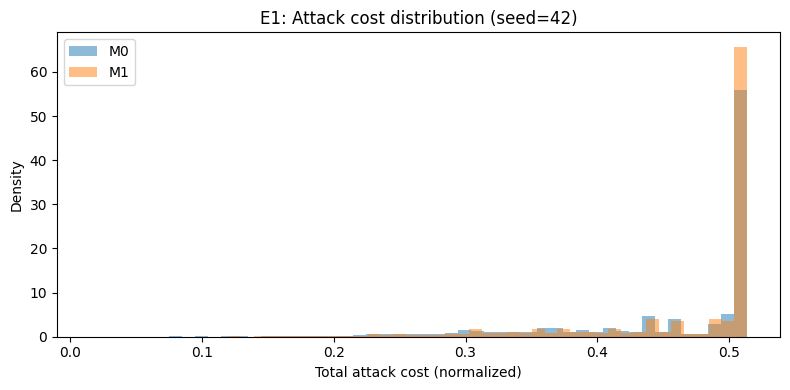

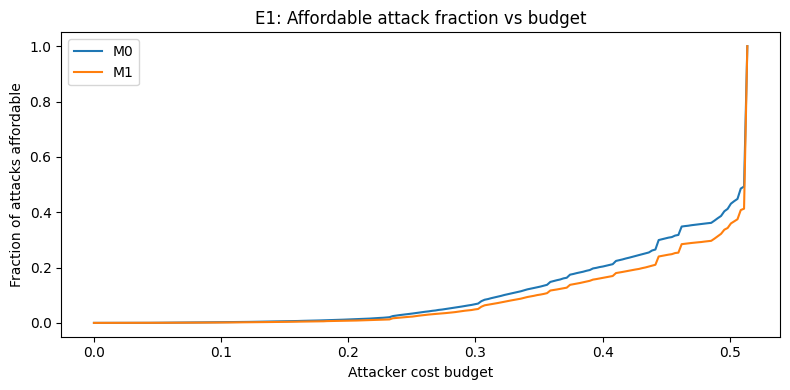

  variant  cost_scale      mean    median       p95
0      M0         1.0  0.459655  0.513811  0.513812
1      M1         1.0  0.470734  0.513812  0.513812
2      M0         2.0  0.919310  1.027622  1.027624
3      M1         2.0  0.941468  1.027624  1.027624
4      M0         0.5  0.229828  0.256906  0.256906
5      M1         0.5  0.235367  0.256906  0.256906


In [9]:
# Cell 13: E1 cost-weighted evaluation (M0 vs M1, seed=42)
import matplotlib.pyplot as plt

# Use training-set ranges for normalization, with winsorization to resist outliers.
# p1/p99 (not min/max) — LCLD annual_inc has extreme tails.
X_train = split_dataset(dataset, test_size=0.2, val_size=0.2, random_state=AUDIT_SEED)[0]
feature_ranges = {}
for feat in FEATURE_COSTS:
    if feat in X_train.columns and np.issubdtype(X_train[feat].dtype, np.number):
        p1, p99 = np.nanpercentile(X_train[feat], [1, 99])
        feature_ranges[feat] = max(p99 - p1, 1e-6)
    else:
        # Categorical: range = 1.0 so an OHE-changed feature contributes exactly COST[f]
        feature_ranges[feat] = 1.0


def reconstruct_ohe_argmax(X_proc: pd.DataFrame, prefix: str) -> pd.Series:
    """Reconstruct a categorical feature as an integer category index via OHE argmax.

    Returns a Series of integer indices (NOT ordered labels). The index values
    are arbitrary (OHE column order is lexical, not ordinal), so consumers
    must compare with (a != o) rather than abs(a - o). Enforced in
    total_cost() via BINARY_COST_FEATURES.
    """
    cols = [c for c in X_proc.columns if c.startswith(f"{prefix}_")]
    if not cols:
        return pd.Series(np.nan, index=X_proc.index)
    return X_proc[cols].values.argmax(axis=1)


def attach_reconstructed_categoricals(X_raw: pd.DataFrame, X_proc: pd.DataFrame) -> pd.DataFrame:
    """Add numeric surrogates for OHE-encoded categoricals we care about in E1.

    term: reconstructed via reconstruct_term_from_ohe (gives 36 or 60).
    emp_length: reconstructed via OHE argmax (gives integer category index).
    Other LCLD categoricals (purpose, home_ownership, addr_state,
    application_type) are not reconstructed — they contribute 0 to E1.
    """
    out = X_raw.copy()
    out["term"] = reconstruct_term_from_ohe(X_proc)
    out["emp_length"] = reconstruct_ohe_argmax(X_proc, "emp_length")
    return out


# Features whose reconstructed raw representation is an OHE-argmax column index
# (i.e. not ordinally meaningful) — cost contribution must be binary changed-or-not,
# not scaled by index gap. See reconstruct_ohe_argmax note above.
BINARY_COST_FEATURES = {"emp_length"}


def total_cost(X_orig_raw: pd.DataFrame, X_adv_raw: pd.DataFrame,
               costs: dict, ranges: dict) -> pd.Series:
    """Per-row attack cost = sum over features of COST[f] * normalized delta.

    Numeric features: |delta| / winsorized_range.
    'term' is ordinal (36 vs 60) and treated as numeric.
    Features in BINARY_COST_FEATURES are treated as categorical — cost
    contribution is COST[f] if the reconstructed category differs, else 0.
    Only features present in both frames contribute. Other categoricals
    (purpose, home_ownership, addr_state, application_type) are NOT
    reconstructed and contribute 0 — documented E1 scope limitation.
    """
    total = pd.Series(0.0, index=X_adv_raw.index)
    for feat, c in costs.items():
        if feat not in X_adv_raw.columns or feat not in X_orig_raw.columns:
            continue
        if feat in BINARY_COST_FEATURES:
            a_raw = X_adv_raw[feat]
            o_raw = X_orig_raw[feat]
            # Compare the reconstructed representations directly.
            changed = (a_raw != o_raw).astype(float)
            total = total + c * changed.fillna(0.0)
            continue
        a = pd.to_numeric(X_adv_raw[feat], errors="coerce")
        o = pd.to_numeric(X_orig_raw[feat], errors="coerce")
        if a.isna().all() or o.isna().all():
            continue
        delta_norm = (a - o).abs() / ranges[feat]
        total = total + c * delta_norm.fillna(0.0)
    return total


# Reconstruct term on the clean side once (adversarial reconstructed per-variant below).
X_test_raw_with_term = attach_reconstructed_categoricals(X_test_raw, X_test_p)

e1_targets = ["M0", "M1"]
e1_costs = {}
for vname in e1_targets:
    X_adv_p = pd.read_parquet(VARIANT_FILES[vname])
    X_adv_raw = inverse_transform_numeric(X_adv_p, num_feature_names, scaler)
    X_adv_raw = attach_reconstructed_categoricals(X_adv_raw, X_adv_p)
    e1_costs[vname] = total_cost(X_test_raw_with_term, X_adv_raw, FEATURE_COSTS, feature_ranges)

# Histogram
fig, ax = plt.subplots(figsize=(8, 4))
for vname, costs_s in e1_costs.items():
    ax.hist(costs_s, bins=50, alpha=0.5, label=vname, density=True)
ax.set_xlabel("Total attack cost (normalized)")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("E1: Attack cost distribution (seed=42)")
plt.tight_layout()
plt.savefig(os.path.join(ADV_SAVE_DIR, "e1_cost_distribution.png"), dpi=150)
plt.show()

# Affordable curve
fig, ax = plt.subplots(figsize=(8, 4))
max_cost = max(c.max() for c in e1_costs.values())
budgets = np.linspace(0, max_cost, 200)
for vname, costs_s in e1_costs.items():
    frac = [(costs_s <= B).mean() for B in budgets]
    ax.plot(budgets, frac, label=vname)
ax.set_xlabel("Attacker cost budget")
ax.set_ylabel("Fraction of attacks affordable")
ax.legend()
ax.set_title("E1: Affordable attack fraction vs budget")
plt.tight_layout()
plt.savefig(os.path.join(ADV_SAVE_DIR, "e1_affordable_curve.png"), dpi=150)
plt.show()

# Summary table (base, x2, x0.5 sensitivity)
sensitivity_rows = []
for scale in (1.0, 2.0, 0.5):
    scaled_costs = {k: v * scale for k, v in FEATURE_COSTS.items()}
    for vname in e1_targets:
        X_adv_p = pd.read_parquet(VARIANT_FILES[vname])
        X_adv_raw = inverse_transform_numeric(X_adv_p, num_feature_names, scaler)
        X_adv_raw = attach_reconstructed_categoricals(X_adv_raw, X_adv_p)
        s = total_cost(X_test_raw_with_term, X_adv_raw, scaled_costs, feature_ranges)
        sensitivity_rows.append({
            "variant": vname, "cost_scale": scale,
            "mean": s.mean(), "median": s.median(), "p95": s.quantile(0.95),
        })

e1_summary = pd.DataFrame(sensitivity_rows)
e1_summary.to_csv(os.path.join(ADV_SAVE_DIR, "e1_cost_summary.csv"), index=False)
print(e1_summary)

In [10]:
# Cell 14: Final summary table + Drive backup
VARIANT_ORDER = ["M0", "M1", "M2", "M3", "M4", "M5", "M6strict", "M6relaxed"]

agg = (
    all_results.groupby("variant")
    .agg({
        "n_mutable": "mean",
        "robust_pr_auc":   ["mean", "std"],
        "robust_accuracy": ["mean", "std"],
        "robust_recall":   ["mean", "std"],
        "robust_f1":       ["mean", "std"],
    })
)
agg.columns = ["_".join(c).strip("_") for c in agg.columns]
agg = agg.reindex(VARIANT_ORDER)

# Merge in seed=42 feasibility numbers (not averaged across seeds — per spec §4)
feas_idx = feas_df.set_index("variant")
agg["feasibility_seed42"] = feas_idx["aggregate"]
agg["g1_pass_seed42"] = feas_idx["g1_installment"]
agg["g4_pass_seed42"] = feas_idx["g4_ohe"]

agg.to_csv(os.path.join(ADV_SAVE_DIR, "mask_ablation_summary.csv"))
with pd.option_context("display.max_columns", None, "display.width", 220,
                       "display.float_format", "{:.4f}".format):
    print(agg)

# --- Drive backup ---
DRIVE_DEST = "/content/drive/MyDrive/FraudBench/results/mask_ablation"
os.makedirs(DRIVE_DEST, exist_ok=True)
for fname in os.listdir(ADV_SAVE_DIR):
    src = os.path.join(ADV_SAVE_DIR, fname)
    dst = os.path.join(DRIVE_DEST, fname)
    shutil.copy(src, dst)
print(f"\nBacked up {len(os.listdir(ADV_SAVE_DIR))} files to {DRIVE_DEST}")


           n_mutable_mean  robust_pr_auc_mean  robust_pr_auc_std  robust_accuracy_mean  robust_accuracy_std  robust_recall_mean  robust_recall_std  robust_f1_mean  robust_f1_std  feasibility_seed42  g1_pass_seed42  \
variant                                                                                                                                                                                                                 
M0               187.6667              0.1051             0.0000                0.0367               0.0070              0.0005             0.0003          0.0002         0.0001              0.0005          0.0140   
M1               122.6667              0.1051             0.0000                0.1419               0.0086              0.0031             0.0008          0.0014         0.0004              0.0018          0.0088   
M2               122.6667              0.1051             0.0000                0.1421               0.0089              0.0032     